Tic tac

In [62]:
import os
import sys
parent_dir = os.path.abspath('..')
sys.path.append(parent_dir) #set root to path so src visible

# Import des librairies
!pip install catboost xgboost lightgbm catboost scikit-learn matplotlib pandas

## Data loading
import s3fs
import time
import pandas as pd
import logging
logging.basicConfig(level=logging.INFO)  #to be able to see the logging info+warnings(to only see warnings: logging.DEBUG)

## Data preprocessing
from src.data_processing.data_load import data_loading
from src.data_processing.data_processing import DataProcessor

In [63]:
#Train Data Loading
#To load data the from the different files directly
df_portefeuille, df_consommations, df_reclamations, df_interactions, df_impayes= data_loading("training")
train_processor = DataProcessor(mode="training")
df_train = train_processor.manual_preprocessing(
        df_portefeuille,
        df_consommations,
        df_reclamations,
        df_interactions,
        df_impayes,)

INFO:src.data_processing.data_processing:Dropped columns from dataset: ['client_structure_familiale', 'client_nom_banque', 'client_nps_verbatim_n', 'client_nps_verbatim_n_moins1', 'impaye_nb_actions', 'impaye_montant_total', 'impaye_duree_max_action_jours', 'impaye_action_1er_impaye', 'impaye_action_1ere_lettre_relance', 'impaye_action_2eme_impaye', 'impaye_action_annonce_contentieux', 'impaye_action_en_recouvrement', 'impaye_action_mise_en_demeure', 'impaye_action_suspension_garanties', 'interaction_historique_mail', 'client_nps_date_reponse_n_moins1_jours', 'client_nps_date_reponse_n_jours']


In [64]:
#Test Data Loading
#To load data the from the different files directly
df_portefeuille, df_consommations, df_reclamations, df_interactions, df_impayes= data_loading("validation")
test_processor = DataProcessor(mode="validation")
df_test = test_processor.manual_preprocessing(
        df_portefeuille,
        df_consommations,
        df_reclamations,
        df_interactions,
        df_impayes,)

INFO:src.data_processing.data_processing:Dropped columns from dataset: ['client_structure_familiale', 'client_nom_banque', 'client_nps_verbatim_n', 'client_nps_verbatim_n_moins1', 'impaye_nb_actions', 'impaye_montant_total', 'impaye_duree_max_action_jours', 'impaye_action_1er_impaye', 'impaye_action_1ere_lettre_relance', 'impaye_action_2eme_impaye', 'impaye_action_annonce_contentieux', 'impaye_action_en_recouvrement', 'impaye_action_mise_en_demeure', 'impaye_action_suspension_garanties', 'interaction_historique_mail', 'client_nps_date_reponse_n_moins1_jours', 'client_nps_date_reponse_n_jours']


In [65]:
[df_train.shape,df_test.shape]

[(132576, 119), (38449, 119)]

In [66]:
# check différences de colonnes
col_train = df_train.columns.to_list()
col_test = df_test.columns.to_list()

diff_train = list(set(col_train)-set(col_test))
diff_test = list(set(col_test)-set(col_train))
print(f"Dans train et pas dans test : {diff_train}")
print(f"Dans Test et pas dans train : {diff_test}")

Dans train et pas dans test : ['recla_motif_Frais']
Dans Test et pas dans train : ['recla_motif_Contestation cotisation']


In [67]:
col_train

['client_code',
 'client_age_souscripteur',
 'client_ro_souscripteur',
 'client_code_postal',
 'client_departement',
 'client_a_conjoint',
 'client_nb_enfants',
 'client_nb_assures_contrat',
 'client_a_garantie_prevoyance',
 'client_produit',
 'client_garantie_base',
 'client_garantie_base_plus_options',
 'client_millesime_tarifaire_produit',
 'client_zone_tarifaire',
 'client_type_zone_tarifaire',
 'client_est_contrat_madelin',
 'client_anciennete_contrat_annees',
 'client_cotisations_annualisees_n_moins2',
 'client_cotisations_annualisees_n_moins1',
 'client_cotisations_annualisees_n',
 'client_cotisations_annualisees_n_plus1',
 'client_mode_paiement',
 'client_frequence_paiement',
 'client_nps_note_reco_n',
 'client_nps_note_reco_n_moins1',
 'courtier_code_partenaire',
 'courtier_anciennete_annees',
 'courtier_code_apporteur',
 'courtier_reseau_courtage',
 'courtier_segmentation_interne',
 'courtier_type_commission',
 'courtier_est_escompte',
 'courtier_nb_affaires_n_moins1',
 'cour

In [68]:
cols_to_drop = [
    "recla_motif_Frais",
    "recla_motif_Contestation cotisation"
]

df_train.drop(columns=cols_to_drop, inplace=True, errors="ignore")
df_test.drop(columns=cols_to_drop, inplace=True, errors="ignore")
df_test = df_test[df_train.columns]

In [69]:
# Définition des X de train et de test et des y de train et de test
X_train = df_train.drop(['target_resiliation_6mois', 'client_code', 'client_code_postal'], axis=1)
y_train = df_train['target_resiliation_6mois']
X_test = df_test.drop(['target_resiliation_6mois', 'client_code', 'client_code_postal'], axis=1)
y_test = df_test['target_resiliation_6mois']

0:	test: 0.7142127	best: 0.7142127 (0)	total: 195ms	remaining: 16m 15s
500:	test: 0.7702502	best: 0.7729059 (183)	total: 1m 2s	remaining: 9m 23s
Stopped by overfitting detector  (500 iterations wait)

bestTest = 0.7729059136
bestIteration = 183

Shrink model to first 184 iterations.
AUC : 0.7729
F1  : 0.3372
              precision    recall  f1-score   support

           0       0.95      0.77      0.85     34549
           1       0.23      0.62      0.34      3900

    accuracy                           0.75     38449
   macro avg       0.59      0.69      0.59     38449
weighted avg       0.87      0.75      0.80     38449

                                    feature  importance
113   client_date_debut_effet_garantie_mois   16.429472
10       client_millesime_tarifaire_produit    7.986685
111                          age_categories    5.081903
27            courtier_segmentation_interne    5.007228
7                            client_produit    4.557432
2                        cl

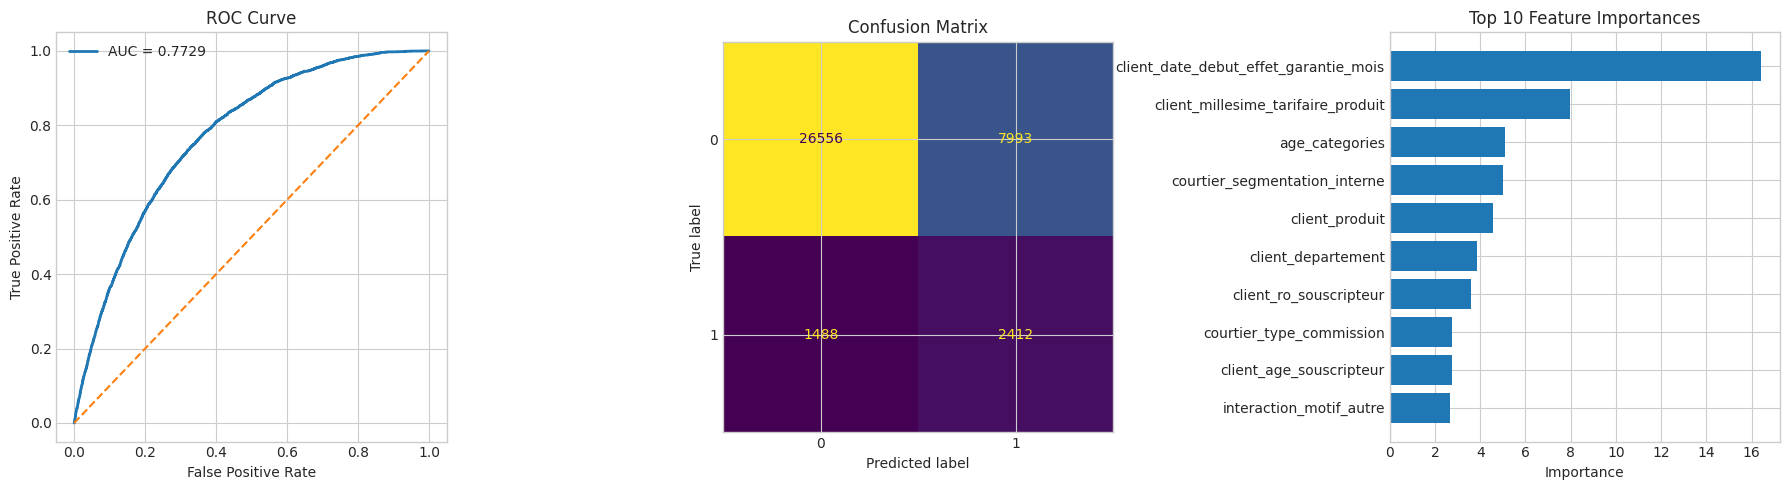

In [70]:
from catboost import CatBoostClassifier
from sklearn.metrics import (
    roc_auc_score, f1_score, classification_report,
    ConfusionMatrixDisplay, roc_curve, auc
)
import pandas as pd
import matplotlib.pyplot as plt

cat_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
for col in cat_features:
    X_train[col] = X_train[col].astype(str).replace("nan", "Missing")
    X_test[col] = X_test[col].astype(str).replace("nan", "Missing")

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

model = CatBoostClassifier(
    iterations=5000,
    learning_rate=0.03,
    depth=10,
    loss_function="Logloss",
    eval_metric="AUC",
    scale_pos_weight=scale_pos_weight,
    random_seed=42,
    verbose=500
)

model.fit(
    X_train, y_train,
    cat_features=cat_features,
    eval_set=(X_test, y_test),
    early_stopping_rounds=500,
    use_best_model=True
)

y_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test).astype(int).ravel()

fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model.get_feature_importance()
}).sort_values("importance", ascending=False)

print(f"AUC : {roc_auc_score(y_test, y_proba):.4f}")
print(f"F1  : {f1_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))
print(feature_importance.head(20))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.4f}")
axes[0].plot([0, 1], [0, 1], "--")
axes[0].set_title("ROC Curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[1], colorbar=False)
axes[1].set_title("Confusion Matrix")

top_feat = feature_importance.head(10)
axes[2].barh(top_feat["feature"][::-1], top_feat["importance"][::-1])
axes[2].set_title("Top 10 Feature Importances")
axes[2].set_xlabel("Importance")

plt.tight_layout()
plt.show()

Colonnes identiques : True
Run 1 | {'depth': 6, 'iterations': 3000, 'l2_leaf_reg': 3, 'learning_rate': 0.03}
Run 2 | {'depth': 6, 'iterations': 3000, 'l2_leaf_reg': 3, 'learning_rate': 0.05}
Run 3 | {'depth': 6, 'iterations': 3000, 'l2_leaf_reg': 5, 'learning_rate': 0.03}
Run 4 | {'depth': 6, 'iterations': 3000, 'l2_leaf_reg': 5, 'learning_rate': 0.05}
Run 5 | {'depth': 6, 'iterations': 3000, 'l2_leaf_reg': 7, 'learning_rate': 0.03}
Run 6 | {'depth': 6, 'iterations': 3000, 'l2_leaf_reg': 7, 'learning_rate': 0.05}
Run 7 | {'depth': 6, 'iterations': 5000, 'l2_leaf_reg': 3, 'learning_rate': 0.03}
Run 8 | {'depth': 6, 'iterations': 5000, 'l2_leaf_reg': 3, 'learning_rate': 0.05}
Run 9 | {'depth': 6, 'iterations': 5000, 'l2_leaf_reg': 5, 'learning_rate': 0.03}
Run 10 | {'depth': 6, 'iterations': 5000, 'l2_leaf_reg': 5, 'learning_rate': 0.05}
Run 11 | {'depth': 6, 'iterations': 5000, 'l2_leaf_reg': 7, 'learning_rate': 0.03}
Run 12 | {'depth': 6, 'iterations': 5000, 'l2_leaf_reg': 7, 'learning

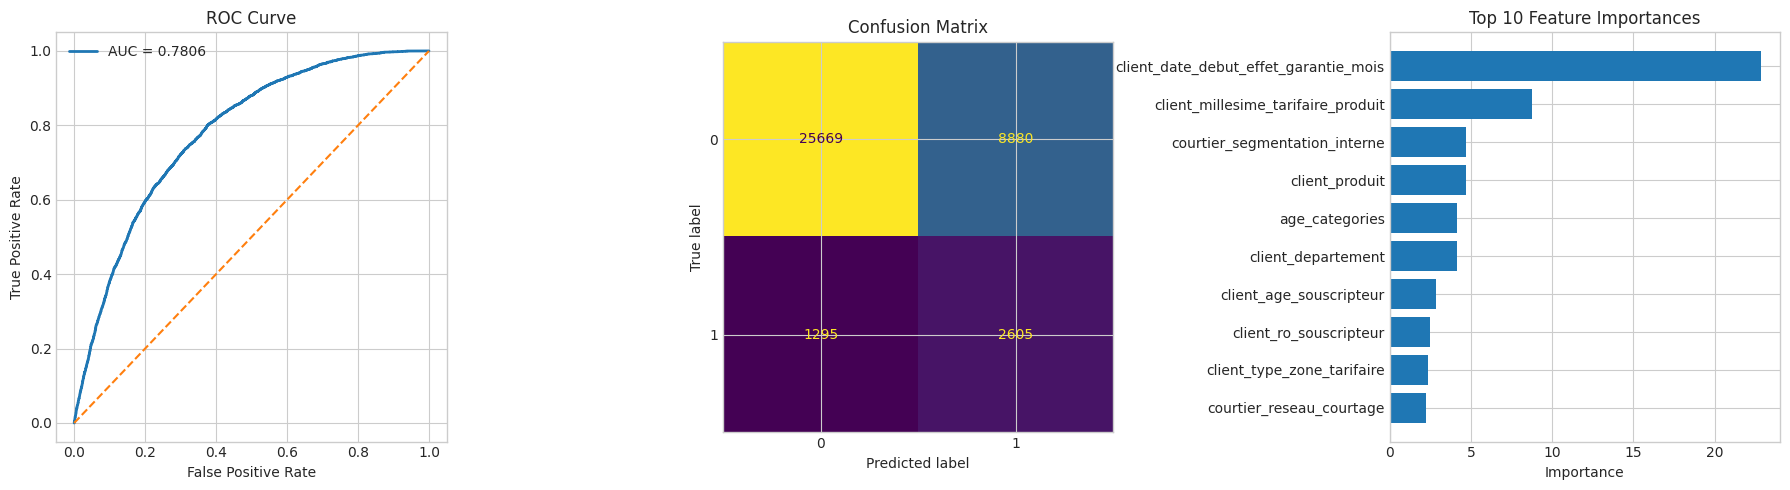

In [71]:
from catboost import CatBoostClassifier
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import (
    roc_auc_score, f1_score, classification_report,
    ConfusionMatrixDisplay, roc_curve, auc
)
import pandas as pd
import matplotlib.pyplot as plt

# 1. Nettoyage minimal
cols_to_drop = ["client_code"]
X_train = X_train.drop(columns=cols_to_drop, errors="ignore")
X_test = X_test.drop(columns=cols_to_drop, errors="ignore")

# 2. Harmonisation train/test
for col in set(X_train.columns) - set(X_test.columns):
    X_test[col] = 0
for col in set(X_test.columns) - set(X_train.columns):
    X_train[col] = 0
X_test = X_test[X_train.columns]

# 3. Variables catégorielles
cat_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
for col in cat_features:
    X_train[col] = X_train[col].astype(str).replace("nan", "Missing")
    X_test[col] = X_test[col].astype(str).replace("nan", "Missing")

print("Colonnes identiques :", (X_train.columns == X_test.columns).all())

# 4. Déséquilibre
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# 5. Grid
param_grid = {
    "depth": [6, 8, 10],
    "learning_rate": [0.03, 0.05],
    "l2_leaf_reg": [3, 5, 7],
    "iterations": [3000, 5000]
}

results = []
best_score = -1
best_model = None
best_params = None

# 6. Recherche grille
for i, params in enumerate(ParameterGrid(param_grid), 1):
    print(f"Run {i} | {params}")

    model = CatBoostClassifier(
        loss_function="Logloss",
        eval_metric="AUC",
        scale_pos_weight=scale_pos_weight,
        random_seed=42,
        verbose=0,
        **params
    )

    model.fit(
        X_train,
        y_train,
        cat_features=cat_features,
        eval_set=(X_test, y_test),
        early_stopping_rounds=300,
        use_best_model=True
    )

    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test).astype(int).ravel()

    auc_score = roc_auc_score(y_test, y_proba)
    f1 = f1_score(y_test, y_pred)

    results.append({
        **params,
        "AUC": auc_score,
        "F1": f1,
        "best_iteration": model.get_best_iteration()
    })

    if auc_score > best_score:
        best_score = auc_score
        best_model = model
        best_params = params

# 7. Résultats du grid
results_df = pd.DataFrame(results).sort_values(["AUC", "F1"], ascending=False).reset_index(drop=True)

print("\nBest params :", best_params)
print("Best AUC    :", round(best_score, 4))
print(results_df.head(10))

# 8. Évaluation finale du meilleur modèle
y_proba = best_model.predict_proba(X_test)[:, 1]
y_pred = best_model.predict(X_test).astype(int).ravel()

auc_score = roc_auc_score(y_test, y_proba)
f1 = f1_score(y_test, y_pred)

print(f"\nFinal AUC : {auc_score:.4f}")
print(f"Final F1  : {f1:.4f}")
print(f"Best iteration : {best_model.get_best_iteration()}")
print(classification_report(y_test, y_pred))

# 9. ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# 10. Feature importance
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": best_model.get_feature_importance()
}).sort_values("importance", ascending=False)

print(feature_importance.head(20))

# 11. Graphiques
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.4f}")
axes[0].plot([0, 1], [0, 1], "--")
axes[0].set_title("ROC Curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[1], colorbar=False)
axes[1].set_title("Confusion Matrix")

top_feat = feature_importance.head(10)
axes[2].barh(top_feat["feature"][::-1], top_feat["importance"][::-1])
axes[2].set_title("Top 10 Feature Importances")
axes[2].set_xlabel("Importance")

plt.tight_layout()
plt.show()

In [72]:
# Import des librairies

## Data loading
import s3fs
import time
import pandas as pd
import logging
logging.basicConfig(level=logging.INFO)  #to be able to see the logging info+warnings(to only see warnings: logging.DEBUG)

## Data preprocessing
from src.data_processing.data_load import data_loading
from src.data_processing.data_processing import DataProcessor
from src.utils.TransformData import dataframe_merge, code_insee_from_communes_as_dict

## ML + evaluation
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, classification_report, confusion_matrix, roc_curve
from sklearn.model_selection import GridSearchCV, StratifiedKFold

In [73]:
# Chargement et preprocessing des données de training et de evaluation

##1. Pre-process training data (scaler and encoder are saved during this process)
train_processor = DataProcessor(mode="training")
df_train = train_processor.run()  #fit training set and save arguments (scaler, ordinal map, target_encoding_maps, ...)

##2. Pre-process test data (by using the same scaler/encoder fitted on training dataset)
test_processor = DataProcessor(mode="validation")

#  HERE:  Reuse the same pre-processor fitted on training dataset (so no data-leakage with target-encoding, normalisation...)
test_processor.target_encoding_maps = train_processor.target_encoding_maps
test_processor.ordinal_maps          = train_processor.ordinal_maps
test_processor.encoded_columns       = train_processor.encoded_columns
test_processor.scaler                = train_processor.scaler
test_processor.normalized_columns    = train_processor.normalized_columns

df_test = test_processor.run_transform() #pre-process test data using same args 

INFO:src.data_processing.data_processing:Dropped columns from dataset: ['client_structure_familiale', 'client_nom_banque', 'client_nps_verbatim_n', 'client_nps_verbatim_n_moins1', 'impaye_nb_actions', 'impaye_montant_total', 'impaye_duree_max_action_jours', 'impaye_action_1er_impaye', 'impaye_action_1ere_lettre_relance', 'impaye_action_2eme_impaye', 'impaye_action_annonce_contentieux', 'impaye_action_en_recouvrement', 'impaye_action_mise_en_demeure', 'impaye_action_suspension_garanties', 'interaction_historique_mail', 'client_nps_date_reponse_n_moins1_jours', 'client_nps_date_reponse_n_jours']
INFO:src.data_processing.data_processing:Columns that are One-hot encoded: ['client_mode_paiement', 'courtier_reseau_courtage', 'courtier_segmentation_interne', 'courtier_type_commission', 'recla_canal_entrant_principale', 'recla_canal_entrant_secondaire']
INFO:src.data_processing.data_processing:Columns that are Target encoded: ['client_ro_souscripteur', 'client_produit', 'client_garantie_base',

In [74]:
[df_train.shape, df_test.shape]# Définition des X de train et de test et des y de train et de test
X_train = df_train.drop(['target_resiliation_6mois', 'client_code', 'client_code_postal'], axis=1)
y_train = df_train['target_resiliation_6mois']
X_test = df_test.drop(['target_resiliation_6mois', 'client_code', 'client_code_postal'], axis=1)
y_test = df_test['target_resiliation_6mois']

In [75]:
mode_values = X_train.mode().iloc[0]
X_train = X_train.fillna(mode_values)
X_test = X_test.fillna(mode_values)

Colonnes identiques : True
Run 1 | {'depth': 6, 'iterations': 3000, 'l2_leaf_reg': 3, 'learning_rate': 0.03}
Run 2 | {'depth': 6, 'iterations': 3000, 'l2_leaf_reg': 3, 'learning_rate': 0.05}
Run 3 | {'depth': 6, 'iterations': 3000, 'l2_leaf_reg': 5, 'learning_rate': 0.03}
Run 4 | {'depth': 6, 'iterations': 3000, 'l2_leaf_reg': 5, 'learning_rate': 0.05}
Run 5 | {'depth': 6, 'iterations': 3000, 'l2_leaf_reg': 7, 'learning_rate': 0.03}
Run 6 | {'depth': 6, 'iterations': 3000, 'l2_leaf_reg': 7, 'learning_rate': 0.05}
Run 7 | {'depth': 6, 'iterations': 5000, 'l2_leaf_reg': 3, 'learning_rate': 0.03}
Run 8 | {'depth': 6, 'iterations': 5000, 'l2_leaf_reg': 3, 'learning_rate': 0.05}
Run 9 | {'depth': 6, 'iterations': 5000, 'l2_leaf_reg': 5, 'learning_rate': 0.03}
Run 10 | {'depth': 6, 'iterations': 5000, 'l2_leaf_reg': 5, 'learning_rate': 0.05}
Run 11 | {'depth': 6, 'iterations': 5000, 'l2_leaf_reg': 7, 'learning_rate': 0.03}
Run 12 | {'depth': 6, 'iterations': 5000, 'l2_leaf_reg': 7, 'learning

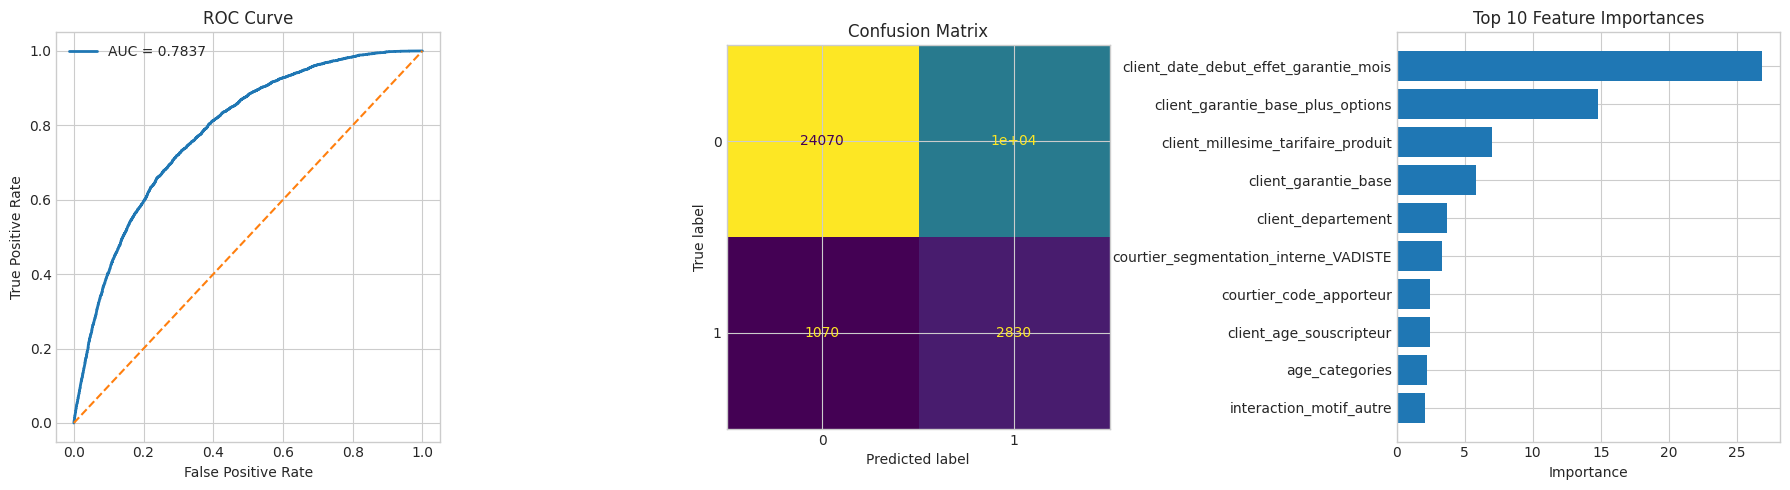

In [76]:
from catboost import CatBoostClassifier
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import (
    roc_auc_score, f1_score, classification_report,
    ConfusionMatrixDisplay, roc_curve, auc
)
import pandas as pd
import matplotlib.pyplot as plt

# 1. Nettoyage minimal
cols_to_drop = ["client_code"]
X_train = X_train.drop(columns=cols_to_drop, errors="ignore")
X_test = X_test.drop(columns=cols_to_drop, errors="ignore")

# 2. Harmonisation train/test
for col in set(X_train.columns) - set(X_test.columns):
    X_test[col] = 0
for col in set(X_test.columns) - set(X_train.columns):
    X_train[col] = 0
X_test = X_test[X_train.columns]

# 3. Variables catégorielles
cat_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
for col in cat_features:
    X_train[col] = X_train[col].astype(str).replace("nan", "Missing")
    X_test[col] = X_test[col].astype(str).replace("nan", "Missing")

print("Colonnes identiques :", (X_train.columns == X_test.columns).all())

# 4. Déséquilibre
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# 5. Grid
param_grid = {
    "depth": [6, 8, 10],
    "learning_rate": [0.03, 0.05],
    "l2_leaf_reg": [3, 5, 7],
    "iterations": [3000, 5000]
}

results = []
best_score = -1
best_model = None
best_params = None

# 6. Recherche grille
for i, params in enumerate(ParameterGrid(param_grid), 1):
    print(f"Run {i} | {params}")

    model = CatBoostClassifier(
        loss_function="Logloss",
        eval_metric="AUC",
        scale_pos_weight=scale_pos_weight,
        random_seed=42,
        verbose=0,
        **params
    )

    model.fit(
        X_train,
        y_train,
        cat_features=cat_features,
        eval_set=(X_test, y_test),
        early_stopping_rounds=300,
        use_best_model=True
    )

    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test).astype(int).ravel()

    auc_score = roc_auc_score(y_test, y_proba)
    f1 = f1_score(y_test, y_pred)

    results.append({
        **params,
        "AUC": auc_score,
        "F1": f1,
        "best_iteration": model.get_best_iteration()
    })

    if auc_score > best_score:
        best_score = auc_score
        best_model = model
        best_params = params

# 7. Résultats du grid
results_df = pd.DataFrame(results).sort_values(["AUC", "F1"], ascending=False).reset_index(drop=True)

print("\nBest params :", best_params)
print("Best AUC    :", round(best_score, 4))
print(results_df.head(10))

# 8. Évaluation finale du meilleur modèle
y_proba = best_model.predict_proba(X_test)[:, 1]
y_pred = best_model.predict(X_test).astype(int).ravel()

auc_score = roc_auc_score(y_test, y_proba)
f1 = f1_score(y_test, y_pred)

print(f"\nFinal AUC : {auc_score:.4f}")
print(f"Final F1  : {f1:.4f}")
print(f"Best iteration : {best_model.get_best_iteration()}")
print(classification_report(y_test, y_pred))

# 9. ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# 10. Feature importance
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": best_model.get_feature_importance()
}).sort_values("importance", ascending=False)

print(feature_importance.head(20))

# 11. Graphiques
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.4f}")
axes[0].plot([0, 1], [0, 1], "--")
axes[0].set_title("ROC Curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[1], colorbar=False)
axes[1].set_title("Confusion Matrix")

top_feat = feature_importance.head(10)
axes[2].barh(top_feat["feature"][::-1], top_feat["importance"][::-1])
axes[2].set_title("Top 10 Feature Importances")
axes[2].set_xlabel("Importance")

plt.tight_layout()
plt.show()


==================== XGBoost ====================
AUC : 0.7686
F1  : 0.3457
              precision    recall  f1-score   support

           0       0.94      0.81      0.87     34549
           1       0.25      0.57      0.35      3900

    accuracy                           0.78     38449
   macro avg       0.60      0.69      0.61     38449
weighted avg       0.87      0.78      0.82     38449



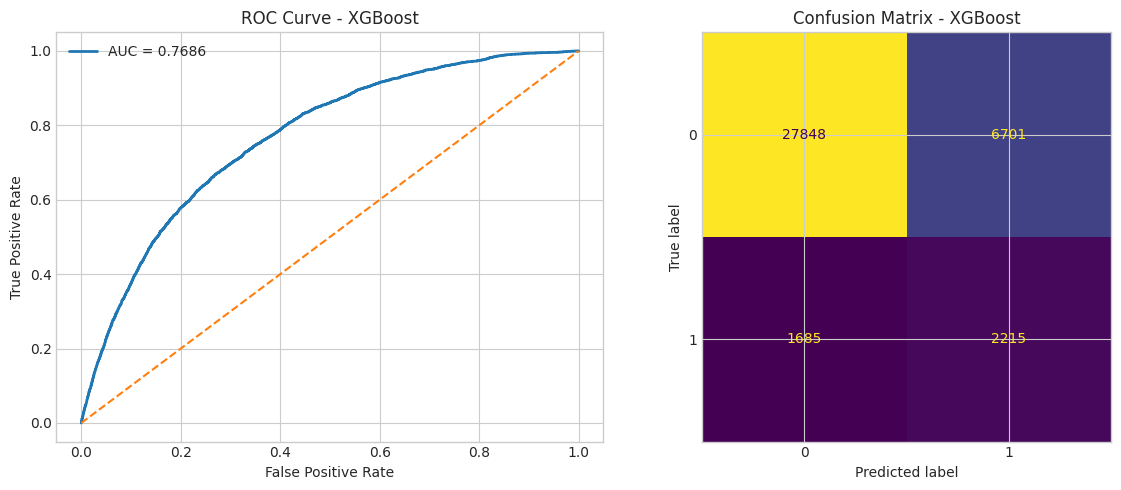


==================== AdaBoost ====================
AUC : 0.7342
F1  : 0.2940
              precision    recall  f1-score   support

           0       0.96      0.63      0.76     34549
           1       0.18      0.74      0.29      3900

    accuracy                           0.64     38449
   macro avg       0.57      0.68      0.53     38449
weighted avg       0.88      0.64      0.71     38449



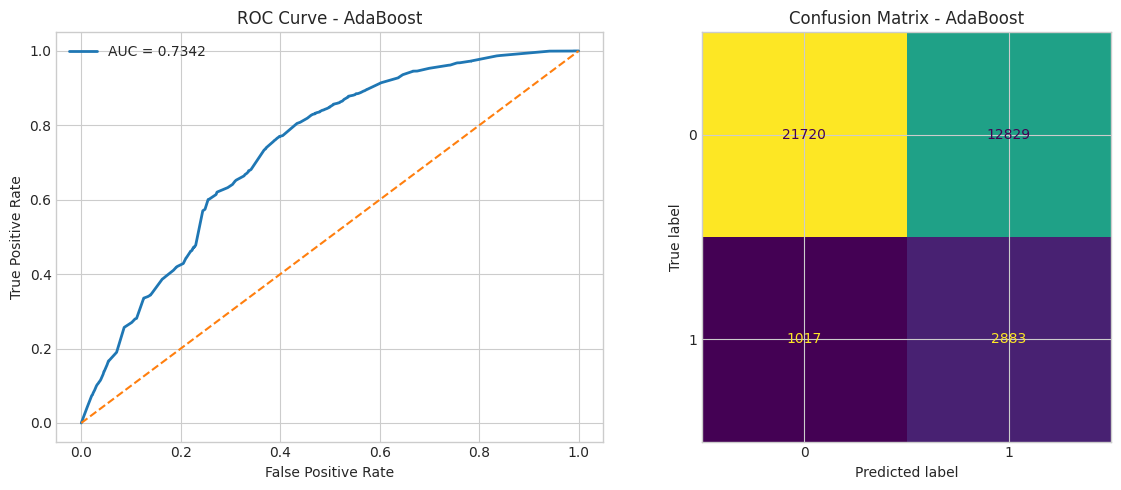


==================== LightGBM ====================
AUC : 0.7500
F1  : 0.2389
              precision    recall  f1-score   support

           0       0.97      0.36      0.53     34549
           1       0.14      0.90      0.24      3900

    accuracy                           0.42     38449
   macro avg       0.55      0.63      0.38     38449
weighted avg       0.89      0.42      0.50     38449



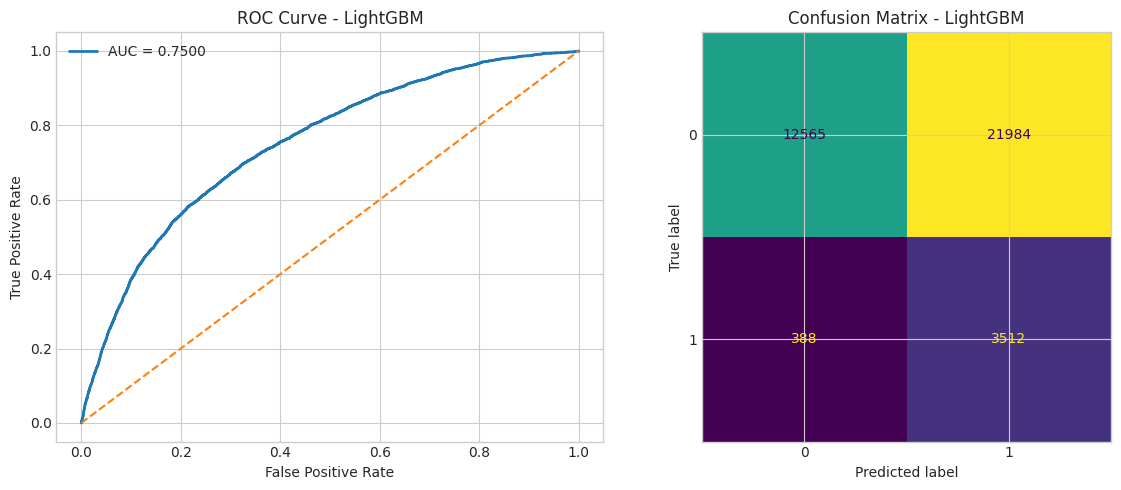


==================== HistGradientBoosting ====================
AUC : 0.7790
F1  : 0.3428
              precision    recall  f1-score   support

           0       0.95      0.75      0.84     34549
           1       0.23      0.66      0.34      3900

    accuracy                           0.74     38449
   macro avg       0.59      0.71      0.59     38449
weighted avg       0.88      0.74      0.79     38449



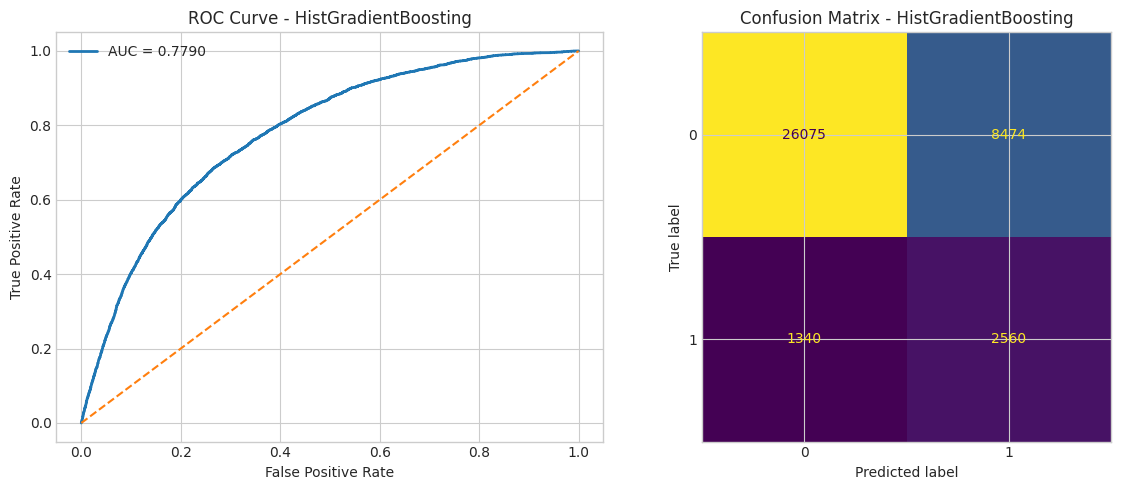


Résumé des performances :
                  Model       AUC        F1
0  HistGradientBoosting  0.778954  0.342842
1               XGBoost  0.768576  0.345662
2              LightGBM  0.749988  0.238944
3              AdaBoost  0.734195  0.294004


In [77]:
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, f1_score, classification_report,
    ConfusionMatrixDisplay, roc_curve, auc
)
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.ensemble import AdaBoostClassifier, HistGradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import pandas as pd
import matplotlib.pyplot as plt

sample_weight = compute_sample_weight(class_weight="balanced", y=y_train)

models = {
    "XGBoost": Pipeline([
        ("model", XGBClassifier(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            eval_metric="logloss"
        ))
    ]),
    
    "AdaBoost": Pipeline([
        ("model", AdaBoostClassifier(
            n_estimators=300,
            learning_rate=0.05,
            random_state=42
        ))
    ]),
    
    "LightGBM": Pipeline([
        ("model", LGBMClassifier(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=6,
            class_weight="balanced",
            random_state=42,
            verbose=-1
        ))
    ]),
    
    "HistGradientBoosting": Pipeline([
        ("model", HistGradientBoostingClassifier(
            max_iter=500,
            learning_rate=0.05,
            max_depth=6,
            random_state=42
        ))
    ])
}

results = []

for name, pipe in models.items():
    pipe.fit(X_train, y_train, model__sample_weight=sample_weight)

    y_proba = pipe.predict_proba(X_test)[:, 1]
    y_pred = pipe.predict(X_test)

    auc_score = roc_auc_score(y_test, y_proba)
    f1 = f1_score(y_test, y_pred)

    results.append({
        "Model": name,
        "AUC": auc_score,
        "F1": f1
    })

    print(f"\n{'='*20} {name} {'='*20}")
    print(f"AUC : {auc_score:.4f}")
    print(f"F1  : {f1:.4f}")
    print(classification_report(y_test, y_pred))

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.4f}")
    axes[0].plot([0, 1], [0, 1], "--")
    axes[0].set_title(f"ROC Curve - {name}")
    axes[0].set_xlabel("False Positive Rate")
    axes[0].set_ylabel("True Positive Rate")
    axes[0].legend()

    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, ax=axes[1], colorbar=False
    )
    axes[1].set_title(f"Confusion Matrix - {name}")

    plt.tight_layout()
    plt.show()

results_df = pd.DataFrame(results).sort_values("AUC", ascending=False).reset_index(drop=True)
print("\nRésumé des performances :")
print(results_df)

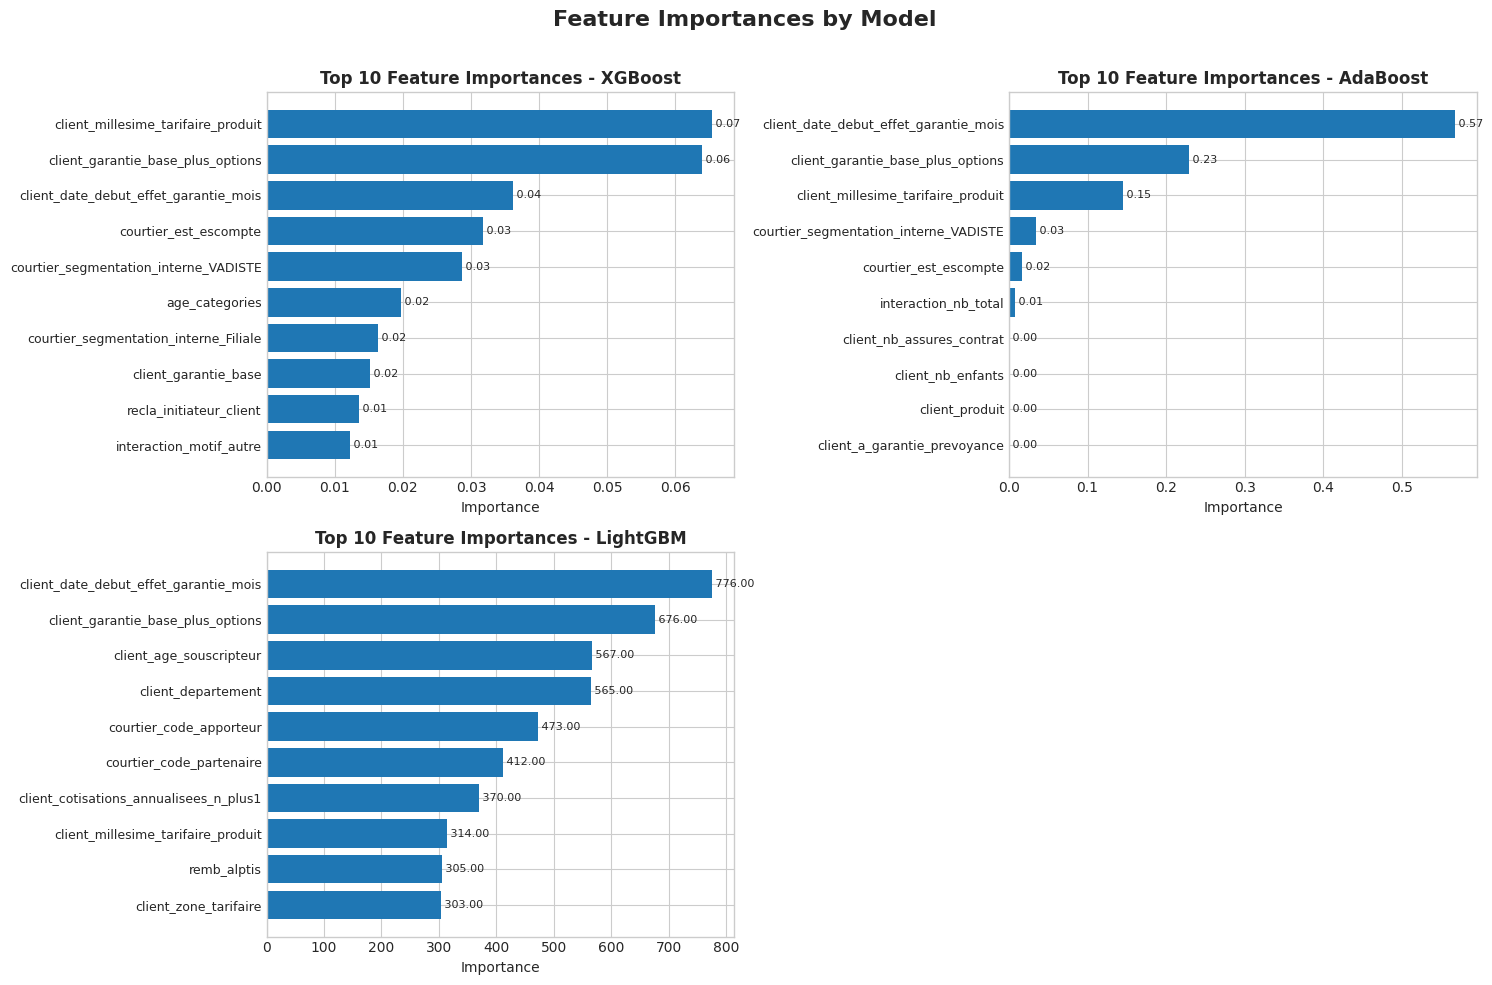

In [78]:
import math
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

models_with_importance = [
    (name, pipe.named_steps["model"])
    for name, pipe in models.items()
    if hasattr(pipe.named_steps["model"], "feature_importances_")
]

n = len(models_with_importance)
ncols = 2
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 5 * nrows))
axes = axes.flatten()

for i, (name, model) in enumerate(models_with_importance):
    feat_imp = pd.DataFrame({
        "feature": X_train.columns,
        "importance": model.feature_importances_
    }).sort_values("importance", ascending=False).head(10)

    bars = axes[i].barh(feat_imp["feature"][::-1], feat_imp["importance"][::-1])
    axes[i].set_title(f"Top 10 Feature Importances - {name}", fontsize=12, fontweight="bold")
    axes[i].set_xlabel("Importance")
    axes[i].tick_params(axis="y", labelsize=9)

    for bar in bars:
        width = bar.get_width()
        axes[i].text(width, bar.get_y() + bar.get_height()/2, f" {width:.2f}", va="center", fontsize=8)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Feature Importances by Model", fontsize=16, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()